In [1]:
import json
import os
import tempfile

import einops
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
import wandb
from load_spd_model2 import load_spd_model
from multitask_sparse_parity import MultitaskSparseParityDataset, MultitaskSparseParityModel
from torch.utils.data import DataLoader
from train_mtsp_model_uniform_task_distribution_modal import TrainConfig
from wandb_utils import load_wandb_model_artifact

from spd.models.component_model import (
    ComponentModel,
    SPDRunInfo,
    handle_deprecated_state_dict_keys_,
)
from spd.models.components import make_mask_infos
from spd.utils.module_utils import expand_module_patterns

/Users/jack/Desktop/Jack/tests/mats-9/scaling/spd-multitasksparseparity/spd/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
target_config, config, model = load_spd_model(
    "mutate/multitask-sparse-parity/runs/oniknm0t",  # d_mlp=14, n_control_bits=2, parity=2
    "wandb:mutate/spd/runs/s-710cd5ea",
)

wandb: Currently logged in as: row (mutate) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


ComponentModel(
  (target_model): MultitaskSparseParityModel(
    (l1): Linear(in_features=32, out_features=14, bias=False)
    (l2): Linear(in_features=14, out_features=2, bias=False)
  )
  (_components): ModuleDict(
    (l1): LinearComponents()
  )
  (_ci_fns): ModuleDict(
    (l1): VectorSharedMLPCiFn(
      (layers): Sequential(
        (0): Linear()
        (1): GELU(approximate='none')
        (2): Linear()
      )
    )
  )
)
tensor(7.0897e-08)
tensor([[-213.7599, -194.5281],
        [-263.0944, -281.2683],
        [-281.5775, -266.0015],
        [-249.3111, -232.7649],
        [-232.7500, -249.6958]])
tensor(7.0897e-08)
tensor(0) tensor([0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0,
        0, 0, 0, 1, 0, 0]) tensor(1)
torch.Size([1024, 200])
torch.Size([1024, 200])
loss_using_components=tensor(1.4052e-06, grad_fn=<NllLossBackward0>)
l1 tensor(0.0141)


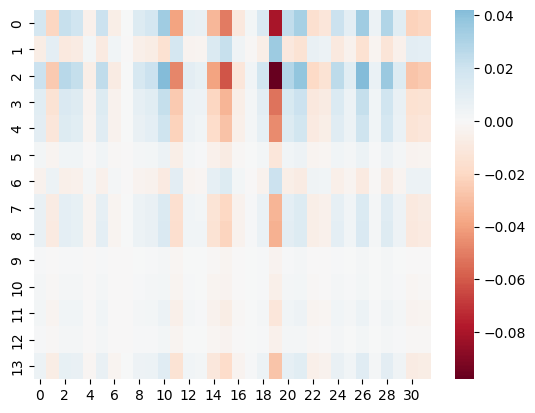

In [3]:
print(model)

dataloader = DataLoader(
    MultitaskSparseParityDataset(
        n_control_bits=target_config.n_control_bits,
        n_task_bits=target_config.n_task_bits,
        n_xored_bits=target_config.n_xored_bits,
        task_distribution_decay_rate=target_config.task_distribution_decay_rate,
        batch_sz=1024,
        size=None,
    ),
    batch_size=None,
)
torch.manual_seed(0)
batch = next(iter(dataloader))
task_ids, task_bits, targets = batch

loss = F.cross_entropy(model(batch), targets)
print(loss)


out = model(batch, cache_type="input")
print(out.output[:5, :])
loss = F.cross_entropy(out.output, targets)
print(loss)


ci_dict = model.calc_causal_importances(
    pre_weight_acts=out.cache,
    detach_inputs=True,
    sampling=config.sampling,
).lower_leaky

# print(ci_dict)

print(task_ids[0], task_bits[0], targets[0])

print(ci_dict["l1"].shape)

layer_names = list(model.target_module_paths)
ci = torch.cat([ci_dict[layer] for layer in layer_names], dim=1)

print(ci.shape)

component_ci_threshold = 0.9
mask_infos = make_mask_infos(
    # component_masks={k: torch.ones_like(v) for k, v in ci_dict.items()},
    # component_masks={k: v for k, v in ci_dict.items()},
    component_masks={k: (v > component_ci_threshold).float() for k, v in ci_dict.items()},
    routing_masks="all",
)

logits_using_components = model(batch, cache_type="input", mask_infos=mask_infos).output
loss_using_components = loss = F.cross_entropy(logits_using_components, targets)
print(f"{loss_using_components=}")

# loss_by_token_using_components = F.cross_entropy(
#     einops.rearrange(logits_using_components[:, :-1], "b seq vocab -> b vocab seq"),
#     batch[:, 1:],
#     reduction="none",
# )
# print(f"mean loss using components = {loss_by_token_using_components.mean().item()}")


for k, v in ci_dict.items():
    print(k, (v > component_ci_threshold).float().mean())


components = model.components["l1"]
einops.einsum(components.V[:, 0], components.U[0], "d_in, d_out -> d_out d_in")

idx = 0
sns.heatmap(
    einops.einsum(components.V[:, idx], components.U[idx], "d_in, d_out -> d_out d_in").detach(),
    cmap="RdBu",
    center=0,
)
plt.show()


In [4]:
idx

0

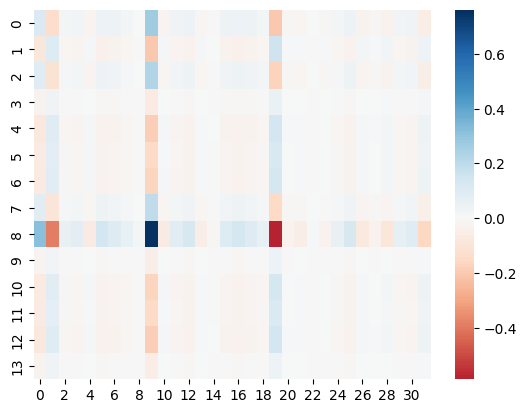

In [17]:
# idx = ci[task_ids == 0].mean(0).sort(descending=True).indices[1]
idx = ci.mean(0).sort(descending=True).indices[6]
# # idx = 73
# idx2 = 2
# print((ci + ((ci[task_ids == 1].mean(0) > 0) * -9999)).mean(0).sort(descending=True).values[idx2])
# idx = (ci + ((ci[task_ids == 1].mean(0) > 0) * -9999)).mean(0).sort(descending=True).indices[idx2]
sns.heatmap(
    einops.einsum(components.V[:, idx], components.U[idx], "d_in, d_out -> d_out d_in").detach(),
    cmap="RdBu",
    center=0,
)
plt.show()

In [6]:
ci.mean(0).sort(descending=True).values > 0

tensor([ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, 

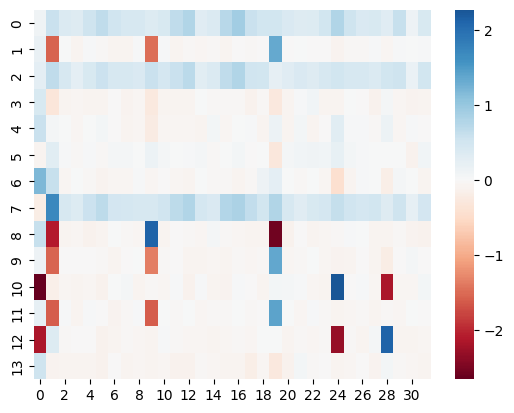

In [7]:
sns.heatmap(
    einops.einsum(
        components.V[:, ci.mean(0) > 0],
        components.U[ci.mean(0) > 0],
        "d_in c, c d_out -> d_out d_in",
    ).detach(),
    cmap="RdBu",
    center=0,
)
plt.show()

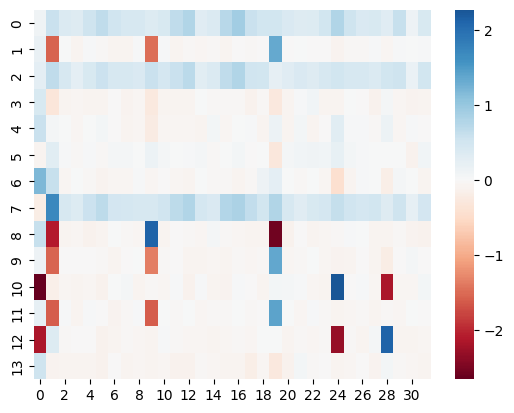

In [8]:
component_mask = ci.mean(0) > 0
sns.heatmap(
    einops.einsum(
        components.V[:, component_mask],
        components.U[component_mask],
        "d_in c, c d_out -> d_out d_in",
    ).detach(),
    cmap="RdBu",
    center=0,
)
plt.show()

In [9]:
component_ci_threshold = 0.9
mask_infos = make_mask_infos(
    # component_masks={k: (v > component_ci_threshold).float() for k, v in ci_dict.items()},
    component_masks={k: (ci.mean(0) > 0.0).float() for k, v in ci_dict.items()},
    routing_masks="all",
)

logits_using_components = model(batch, cache_type="input", mask_infos=mask_infos).output
loss_using_components = loss = F.cross_entropy(logits_using_components, targets)
print(f"{loss_using_components=}")

loss_using_components=tensor(0.0007, grad_fn=<NllLossBackward0>)


In [10]:
(ci + ((ci[task_ids == 1].mean(0) > 0) * -9999)).mean(0).sort(descending=True)

torch.return_types.sort(
values=tensor([ 1.8456e-01,  1.8425e-01,  1.8369e-01,  1.8359e-01,  1.8359e-01,
         5.5166e-02,  2.3925e-02,  1.5030e-04,  9.3222e-05,  1.0210e-05,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00

In [11]:
ci[:, ci[task_ids == 1].mean(0) == 0][task_ids == 0].mean(0).sort(descending=True)

torch.return_types.sort(
values=tensor([2.5199e-01, 2.5156e-01, 2.5080e-01, 2.5067e-01, 2.5067e-01, 7.5319e-02,
        3.2666e-02, 2.0522e-04, 1.2728e-04, 1.3941e-05, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        

In [12]:
(ci[task_ids == 1].mean(0) == 0).shape

torch.Size([200])

In [13]:
ci[torch.arange(ci.shape[0]), (ci[task_ids == 1].mean(0) == 0)]

IndexError: shape mismatch: indexing tensors could not be broadcast together with shapes [1024], [179]

In [ ]:
ci[task_ids == 0, idx].mean()

tensor(0.2503, grad_fn=<MeanBackward0>)

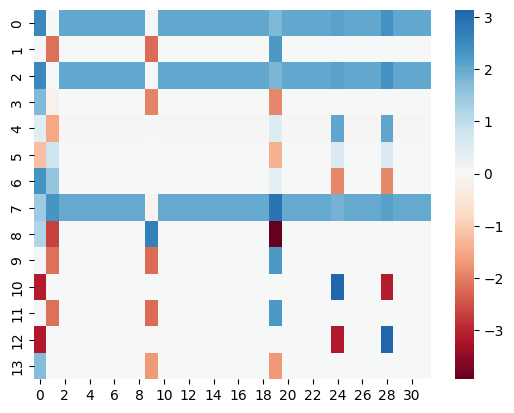

In [ ]:
sns.heatmap(
    model.target_model.l1.weight.data,
    cmap="RdBu",
    center=0,
)
plt.show()

In [ ]:
ci[task_ids == 0].mean(0).sort(descending=True)

torch.return_types.sort(
values=tensor([4.9733e-01, 4.9733e-01, 4.9693e-01, 4.9687e-01, 2.5298e-01, 2.5200e-01,
        2.5181e-01, 2.5160e-01, 2.5041e-01, 2.5027e-01, 2.4339e-01, 1.9954e-01,
        3.4232e-02, 3.6799e-04, 3.6814e-05, 2.0081e-05, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        

In [ ]:
(ci[task_ids == 0].mean(0) - ci.mean(0)).sort(descending=True)

torch.return_types.sort(
values=tensor([ 1.0076e-01,  6.7430e-02,  6.7378e-02,  6.7004e-02,  6.6967e-02,
         6.5126e-02,  5.3392e-02,  2.7153e-02,  1.2958e-02,  1.2958e-02,
         1.2851e-02,  9.8505e-06,  5.3731e-06,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00

In [ ]:
task_ids

tensor([0, 0, 1,  ..., 1, 0, 1])

<Axes: >

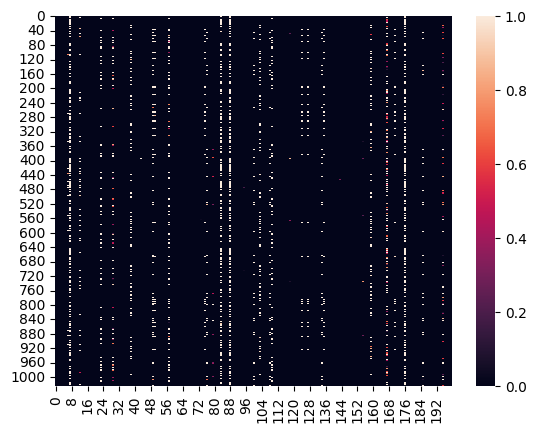

In [ ]:
sns.heatmap(ci.detach())

In [ ]:
ci.mean(0).sort()

torch.return_types.sort(
values=tensor([0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        

In [ ]:
component_ci_threshold = 0.9
mask_infos = make_mask_infos(
    component_masks={k: (v > component_ci_threshold).float() for k, v in ci_dict.items()},
    routing_masks="all",
)

logits_using_components = model(batch, cache_type="input", mask_infos=mask_infos).output
loss_using_components = loss = F.cross_entropy(logits_using_components, targets)
print(f"{loss_using_components=}")

loss_using_components=tensor(2.0290e-07, grad_fn=<NllLossBackward0>)


In [ ]:
targets

tensor([1, 0, 1,  ..., 0, 1, 1])

In [ ]:
ci[3]

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.2183, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 1.0000, 0.0000, 0.0000, 

In [ ]:
logits_using_components

tensor([[-28.0078,   3.0981],
        [-22.0258, -43.3700],
        [-47.8338,  -4.9890],
        ...,
        [-16.1663, -35.7616],
        [-33.5648,   3.7453],
        [-35.8596,   1.7261]], grad_fn=<MmBackward0>)